# Análise Exploratória de Dados Astronômicos

Este notebook apresenta uma análise exploratória de um conjunto de dados de estrelas, com o objetivo de compreender a estrutura do dataset e interpretar a distribuição das variáveis.

## Importação das bibliotecas

Nesta etapa, são importadas as bibliotecas necessárias para manipulação e visualização dos dados.

In [ ]:
import pandas as pd #ler e analisar a tabela
import matplotlib.pyplot as plt #para gráficos
import seaborn as sns #para gráficos mais bonitos e correlação


## Leitura dos dados

Os dados são carregados a partir de um arquivo CSV e armazenados em um DataFrame.

O comando `head()` permite visualizar as primeiras linhas do dataset, facilitando a verificação inicial da estrutura dos dados.

In [14]:
df = pd.read_csv("cleaned_star_data.csv") #lê o arquivo CSV
df.head() #mostra as primeiras 5 linhas

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3042,0.0005,0.1542,16.6,0.0,Red,M
2,2600,0.0003,0.102,18.7,0.0,Red,M
3,2800,0.0002,,16.65,0.0,Red,M
4,1939,0.000138,0.103,20.06,0.0,Red,M


## Estrutura do dataset

Em seguida, são analisadas as dimensões e os nomes das colunas do dataset.

In [15]:
#ver o tamanho do dataset
print("Quantidade de linhas:",df.shape[0])
print("Quantidade de colunas:",df.shape[1])

Quantidade de linhas: 240
Quantidade de colunas: 7


In [17]:
#ver os nomes das colunas
print(df.columns.tolist())

['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)', 'Absolute magnitude(Mv)', 'Star type', 'Star color', 'Spectral Class']


## Informações gerais dos dados

O método `info()` fornece um resumo das colunas, incluindo tipos de dados e valores não nulos.

In [18]:
#entender os tipos das colunas
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         239 non-null    str    
 1   Luminosity(L/Lo)        239 non-null    str    
 2   Radius(R/Ro)            239 non-null    str    
 3   Absolute magnitude(Mv)  239 non-null    str    
 4   Star type               239 non-null    float64
 5   Star color              239 non-null    str    
 6   Spectral Class          239 non-null    str    
dtypes: float64(1), str(6)
memory usage: 13.3 KB


## Verificação de valores ausentes

Posteriormente, verifica-se a presença de dados faltantes no dataset.

In [19]:
#verificar valores ausentes
df.isnull().sum()

Temperature (K)           1
Luminosity(L/Lo)          1
Radius(R/Ro)              1
Absolute magnitude(Mv)    1
Star type                 1
Star color                1
Spectral Class            1
dtype: int64

A identificação de valores ausentes é importante para garantir a qualidade da análise.

## Estatísticas descritivas

O método `describe()` fornece um resumo estatístico das variáveis numéricas.Apenas a variável "Star type" foi considerada numérica nesta etapa, indicando a necessidade de conversão de outras colunas.

In [20]:
#estatística descritiva
df.describe()

,Star type
count,239.00000
mean,2.51046
std,1.70728
min,0.00000
25%,1.00000
50%,3.00000
75%,4.00000
max,5.00000


Essas estatísticas incluem média, desvio padrão, valores mínimos e máximos, além dos quartis, que ajudam a entender a distribuição dos dados.

## Limpeza dos dados

As linhas com valores ausentes são removidas para evitar problemas na análise.

In [24]:
df = df.dropna()

## Análise dos tipos de estrelas

Nesta etapa, é analisada a distribuição das categorias da variável "Star type".

In [32]:
#contar categorias
df["Star type"].value_counts()

Star type
1.0    40
2.0    40
3.0    40
4.0    40
5.0    40
0.0    39
Name: count, dtype: int64

## Conversão de dados e Análise da distribuição da temperatura

A coluna de temperatura é convertida para formato numérico para permitir análises e visualizações. Foi utilizado um boxplot para analisar a distribuição da temperatura das estrelas.


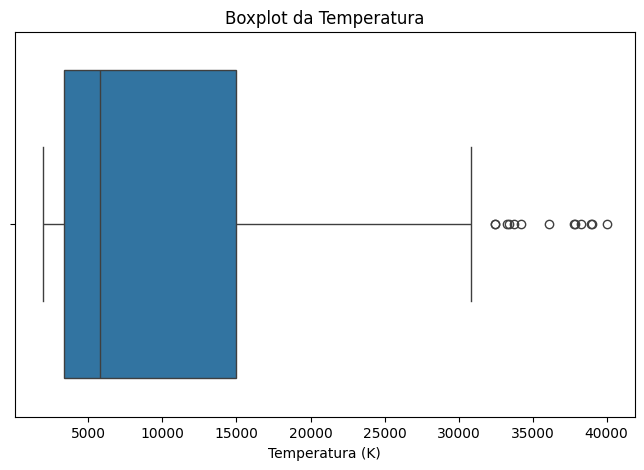

In [34]:
df["Temperature (K)"] = pd.to_numeric(df["Temperature (K)"], errors="coerce")
df = df.dropna()

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Temperature (K)"])

plt.title("Boxplot da Temperatura")
plt.xlabel("Temperatura (K)")

plt.show()

O boxplot mostra a mediana, que divide os dados em duas partes iguais, além da dispersão e possíveis valores extremos. Observa-se uma assimetria à direita, indicando que existem valores de temperatura significativamente maiores que a maioria.Também, observa-se que a mediana não está centralizada na caixa, reforçando a assimetria na distribuição dos dados.

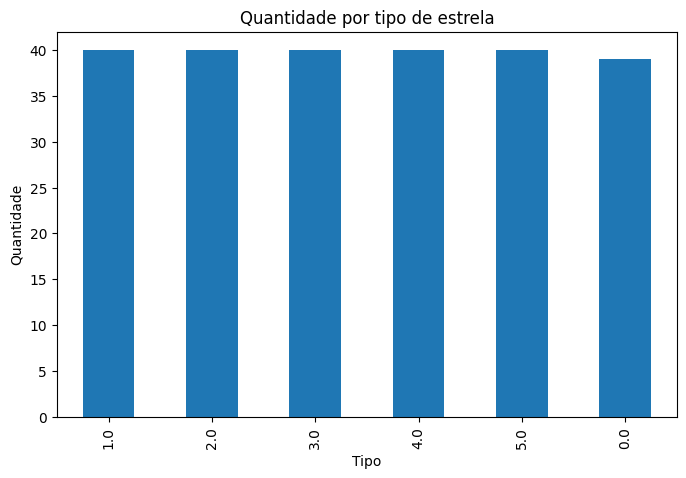

In [33]:
#gráfico categorias
plt.figure(figsize=(8,5))
df["Star type"].value_counts().plot(kind="bar")
plt.title("Quantidade por tipo de estrela")
plt.xlabel("Tipo")
plt.ylabel("Quantidade")
plt.show()

O gráfico mostra que os tipos de estrelas estão distribuídos de forma bastante equilibrada no dataset.

## Conclusão

A análise exploratória permitiu compreender a estrutura do dataset, identificar padrões e observar a distribuição das variáveis. Foi possível verificar a presença de valores extremos e interpretar o comportamento das temperaturas das estrelas, contribuindo para uma compreensão inicial dos dados. A presença de valores extremos indica uma grande variabilidade na temperatura das estrelas, o que pode estar relacionado a diferentes classificações estelares.